In [1]:
import pandas as pd

# Load the data from the parquet file
df = pd.read_parquet('/kaggle/input/dataset/data.parquet')

#df.head()
df.index = pd.to_datetime(df.index)

df.ffill()


,banknifty,nifty,tte
time,,,
2021-01-01 09:15:00,0.286058,0.199729,27
2021-01-01 09:16:00,0.285381,0.200433,27
2021-01-01 09:17:00,0.284233,0.200004,27
2021-01-01 09:18:00,0.286104,0.199860,27
2021-01-01 09:19:00,0.285539,0.198951,27
...,...,...,...
2022-06-30 15:26:00,0.240701,0.214758,28
2022-06-30 15:27:00,0.240875,0.216558,28
2022-06-30 15:28:00,0.242115,0.216794,28


In [2]:
# Calculate spread and P/L
df['spread'] = df['banknifty'] - df['nifty']
df['pnl'] = df['spread'] * (df['tte'] ** 0.7)

#df[['spread', 'pnl']].head()

Grid search for Finding Optimal parameter


In [3]:

def grid():
    import numpy as np
    from tqdm import tqdm

    # Define parameter grid
    entry_z_list = np.arange(1.5, 3.1, 0.2)
    exit_z_list = np.arange(0, 1.1, 0.2)
    window_list = [30, 60, 90, 120, 180]

    results = []

    for window in tqdm(window_list, desc="Window"):
        spread_mean = df['spread'].rolling(window).mean()
        spread_std = df['spread'].rolling(window).std()
        zscore = (df['spread'] - spread_mean) / spread_std

        for entry_z in entry_z_list:
            for exit_z in exit_z_list:
                position = 0
                positions = np.zeros(len(df))
                for i in range(window, len(df)):
                    if position == 0:
                        if zscore.iloc[i] > entry_z:
                            position = -1
                        elif zscore.iloc[i] < -entry_z:
                            position = 1
                    elif position == 1 and zscore.iloc[i] >= exit_z:
                        position = 0
                    elif position == -1 and zscore.iloc[i] <= -exit_z:
                        position = 0
                    positions[i] = position

                strategy_pnl = np.roll(positions, 1) * df['pnl'].values
                strategy_pnl[0] = 0  
                cum_strategy_pnl = np.cumsum(strategy_pnl)
                # Resample to daily PnL for Sharpe
                temp_df = df.copy()
                temp_df['strategy_pnl'] = strategy_pnl
                daily_pnl = temp_df['strategy_pnl'].resample('D').sum()
                daily_pnl = daily_pnl[daily_pnl != 0]
                sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
                abs_return = cum_strategy_pnl[-1]
                rolling_max = np.maximum.accumulate(cum_strategy_pnl)
                drawdown = cum_strategy_pnl - rolling_max
                max_drawdown = drawdown.min()
                results.append({
                    'window': window,
                    'entry_z': entry_z,
                    'exit_z': exit_z,
                    'abs_return': abs_return,
                    'sharpe': sharpe,
                    'max_drawdown': max_drawdown
                })

    #sort by sharpe
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='sharpe', ascending=False)
    results_df.head(10)
    return results_df
import pickle
import os

cache_path = 'grid_search_results.pkl'

# Check if cache exists
if os.path.exists(cache_path) and os.path.getsize(cache_path) > 0:
    with open(cache_path, 'rb') as f:
        results_df = pickle.load(f)
    print("Loaded grid search results from cache.")
else:
    results_df = grid()
    with open(cache_path, 'wb') as f:
        pickle.dump(results_df, f)
    print("Computed and cached grid search results.")

Window: 100%|██████████| 5/5 [18:27<00:00, 221.55s/it]

Computed and cached grid search results.


In [4]:
#sort by abs_return
results_df = results_df.sort_values(by='abs_return', ascending=False)
results_df.head(10)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,window,entry_z,exit_z,abs_return,sharpe,max_drawdown
174,120,2.5,0.0,NaN,5.087098,NaN
132,90,2.7,0.0,NaN,4.851999,NaN
110,90,1.9,0.4,NaN,4.840235,NaN
104,90,1.7,0.4,NaN,4.838711,NaN
116,90,2.1,0.4,NaN,4.786399,NaN
180,120,2.7,0.0,NaN,4.782701,NaN
120,90,2.3,0.0,NaN,4.778360,NaN
202,180,1.7,0.8,NaN,4.717297,NaN
92,60,2.9,0.4,NaN,4.674504,NaN
150,120,1.7,0.0,NaN,4.673067,NaN


In [5]:
import numpy as np

# Parameters
window = 90
entry_z = 1.5
exit_z = 0.8

# Calculate rolling mean and std for spread
df['spread_mean'] = df['spread'].rolling(window).mean()
df['spread_std'] = df['spread'].rolling(window).std()
df['zscore'] = (df['spread'] - df['spread_mean']) / df['spread_std']

# Initialize position and PnL columns
df['position'] = 0  # 1 for long, -1 for short, 0 for flat

# Generate signals
position = 0
for i in range(window, len(df)):
    if position == 0:
        if df['zscore'].iloc[i] > entry_z:
            position = -1  # Short spread
        elif df['zscore'].iloc[i] < -entry_z:
            position = 1   # Long spread
    elif position == 1 and df['zscore'].iloc[i] >= exit_z:
        position = 0
    elif position == -1 and df['zscore'].iloc[i] <= -exit_z:
        position = 0
    df.at[df.index[i], 'position'] = position

# Calculate strategy PnL (shift position to avoid lookahead bias)
df['strategy_pnl'] = df['position'].shift().fillna(0) * df['pnl']

# Cumulative PnL
df['cum_strategy_pnl'] = df['strategy_pnl'].cumsum()

# Display results
df[['spread', 'zscore', 'position', 'strategy_pnl', 'cum_strategy_pnl']].tail()

,spread,zscore,position,strategy_pnl,cum_strategy_pnl
time,,,,,
2022-06-30 15:26:00,0.025943,0.232729,0,0.0,58883.42365
2022-06-30 15:27:00,0.024317,-1.120705,0,0.0,58883.42365
2022-06-30 15:28:00,0.025321,-0.271727,0,0.0,58883.42365
2022-06-30 15:29:00,0.026971,1.105138,0,0.0,58883.42365
2022-06-30 15:30:00,0.025827,0.134940,0,0.0,58883.42365


In [6]:
import numpy as np

# Absolute Return 
absolute_return = df['cum_strategy_pnl'].iloc[-1]
print(f"Absolute Return: {absolute_return:.2f}")

daily_pnl = df['strategy_pnl'].resample('D').sum()
daily_pnl = daily_pnl[daily_pnl != 0]  # Remove non-trading days

# Sharpe Ratio (assuming risk-free rate = 0)
sharpe_ratio = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")

# Max Drawdown
cum_pnl = df['cum_strategy_pnl'].fillna(0)
rolling_max = cum_pnl.cummax()
drawdown = cum_pnl - rolling_max
max_drawdown = drawdown.min()
print(f"Max Drawdown: {max_drawdown:.2f}")



Absolute Return: 58883.42
Annualized Sharpe Ratio: 4.09
Max Drawdown: -60672.21


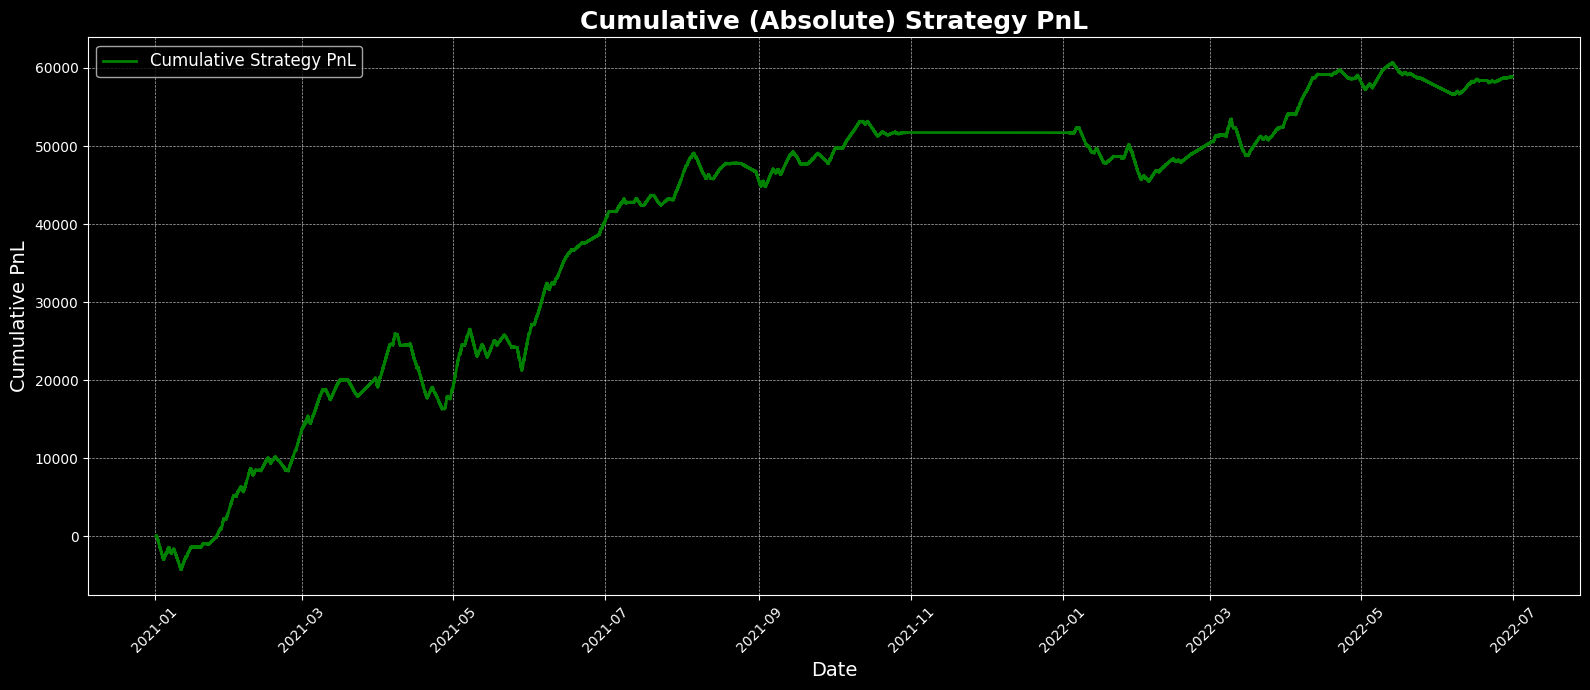

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('dark_background')  

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df.index, df['cum_strategy_pnl'], label='Cumulative Strategy PnL', color='green', linewidth=2)

# Highlight max drawdown
# rolling_max = df['cum_strategy_pnl'].cummax()
# drawdown = df['cum_strategy_pnl'] - rolling_max
# min_dd_idx = drawdown.idxmin()
# ax.axvline(min_dd_idx, color='red', linestyle='--', alpha=0.5, label='Max Drawdown Point')

# Formatting
ax.set_title('Cumulative (Absolute) Strategy PnL', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Cumulative PnL', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()